# 🤖 AI & Machine Learning — Task 3
## Model Validation, Overfitting Control & Hyperparameter Tuning
**Maincrafts Technology Internship**

---

### 🎯 Objective
Building on Task-2, this notebook dives into **professional ML validation techniques**:
- Detect and control **overfitting** in machine learning models
- Validate models using **5-Fold Cross-Validation**
- Tune hyperparameters systematically with **GridSearchCV**
- Improve **generalization** to unseen data
- Justify the **best model selection** scientifically

> 📌 **Dataset**: California Housing Dataset (same as Task-2 for fair comparison)

---
## Step 1 — Import Libraries

In [1]:
import sys, io, os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Notebook display style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

COLORS = {'lr': '#4C72B0', 'ridge': '#55A868', 'tree': '#C44E52', 'tuned': '#8172B2', 'cv': '#DD8452'}

print('✅ Libraries loaded successfully')
import sklearn
print(f'   sklearn version : {sklearn.__version__}')
print(f'   pandas version  : {pd.__version__}')
print(f'   numpy version   : {np.__version__}')

✅ Libraries loaded successfully
   sklearn version : 1.6.1
   pandas version  : 2.3.3
   numpy version   : 2.0.2


---
## Step 2 — Load and Prepare Dataset

In [2]:
# Load California Housing Dataset
data = fetch_california_housing(as_frame=True)
df   = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)

print('=== California Housing Dataset ===')
print(f'Shape       : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Target      : HousePrice (Median House Value in $100,000s)')
print(f'Missing Val : {df.isnull().sum().sum()}')
print()
df.head()

=== California Housing Dataset ===
Shape       : 20640 rows × 9 columns
Target      : HousePrice (Median House Value in $100,000s)
Missing Val : 0



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,2401.0000,2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220


In [3]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697,2.0686
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035,1.1540
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500,0.1500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000,1.1960
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900,1.7970
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100,2.6472
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100,5.0000


In [4]:
# Separate features and target
X = df.drop('HousePrice', axis=1)
y = df['HousePrice']

print(f'X (Features) shape : {X.shape}')
print(f'y (Target) shape   : {y.shape}')
print(f'Features           : {list(X.columns)}')

X (Features) shape : (20640, 8)
y (Target) shape   : (20640,)
Features           : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


---
## Step 3 — Feature Scaling (StandardScaler)

In [5]:
# Apply StandardScaler — same as Task-2 for continuity
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('StandardScaler applied:')
print(f'  Before — Feature means : {X.mean().round(3).values}')
print(f'  After  — Feature means : {X_scaled.mean(axis=0).round(6)}')
print(f'  After  — Feature stds  : {X_scaled.std(axis=0).round(6)}')
print()
print('✅ All features now have mean≈0 and std≈1')

StandardScaler applied:
  Before — Feature means : [ 3.871000e+00  2.863900e+01  5.429000e+00  1.097000e+00  1.425477e+03
  3.071000e+00  3.563200e+01 -1.195700e+02]
  After  — Feature means : [ 0.  0.  0. -0. -0.  0. -0. -0.]
  After  — Feature stds  : [1. 1. 1. 1. 1. 1. 1. 1.]

✅ All features now have mean≈0 and std≈1


---
## Step 4 — Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print('Train-Test Split (80% / 20%):')
print(f'  Training samples : {X_train.shape[0]}')
print(f'  Test samples     : {X_test.shape[0]}')
print(f'  Random state     : 42 (reproducible)')

Train-Test Split (80% / 20%):
  Training samples : 16512
  Test samples     : 4128
  Random state     : 42 (reproducible)


---
## Step 5 — Detect Overfitting (Untuned Decision Tree)

> **Key Concept**: A model that perfectly fits training data but performs poorly on test data is **overfitting**. We detect it by comparing **Train RMSE vs Test RMSE**.

In [7]:
# Train an untuned Decision Tree — observe the overfitting
tree_raw = DecisionTreeRegressor(random_state=42)  # No constraints = full tree
tree_raw.fit(X_train, y_train)

# Predict on both Train and Test
train_pred_raw = tree_raw.predict(X_train)
test_pred_raw  = tree_raw.predict(X_test)

train_rmse_raw = np.sqrt(mean_squared_error(y_train, train_pred_raw))
test_rmse_raw  = np.sqrt(mean_squared_error(y_test,  test_pred_raw))
train_r2_raw   = r2_score(y_train, train_pred_raw)
test_r2_raw    = r2_score(y_test,  test_pred_raw)

print('=== Untuned Decision Tree Performance ===')
print(f'  Train RMSE : {train_rmse_raw:.4f}')
print(f'  Test  RMSE : {test_rmse_raw:.4f}')
print(f'  Train R²   : {train_r2_raw:.4f}')
print(f'  Test  R²   : {test_r2_raw:.4f}')
print()
gap = test_rmse_raw - train_rmse_raw
print(f'  ⚠️  Overfitting Gap (Test - Train RMSE): {gap:.4f}')
print(f'  ⚠️  Train R² = {train_r2_raw:.4f} → Perfect fit on training (MEMORIZED!)')
print(f'  ⚠️  Test  R² = {test_r2_raw:.4f} → Poor generalization to new data')

=== Untuned Decision Tree Performance ===
  Train RMSE : 0.0000
  Test  RMSE : 0.7030
  Train R²   : 1.0000
  Test  R²   : 0.6228

  ⚠️  Overfitting Gap (Test - Train RMSE): 0.7030
  ⚠️  Train R² = 1.0000 → Perfect fit on training (MEMORIZED!)
  ⚠️  Test  R² = 0.6228 → Poor generalization to new data


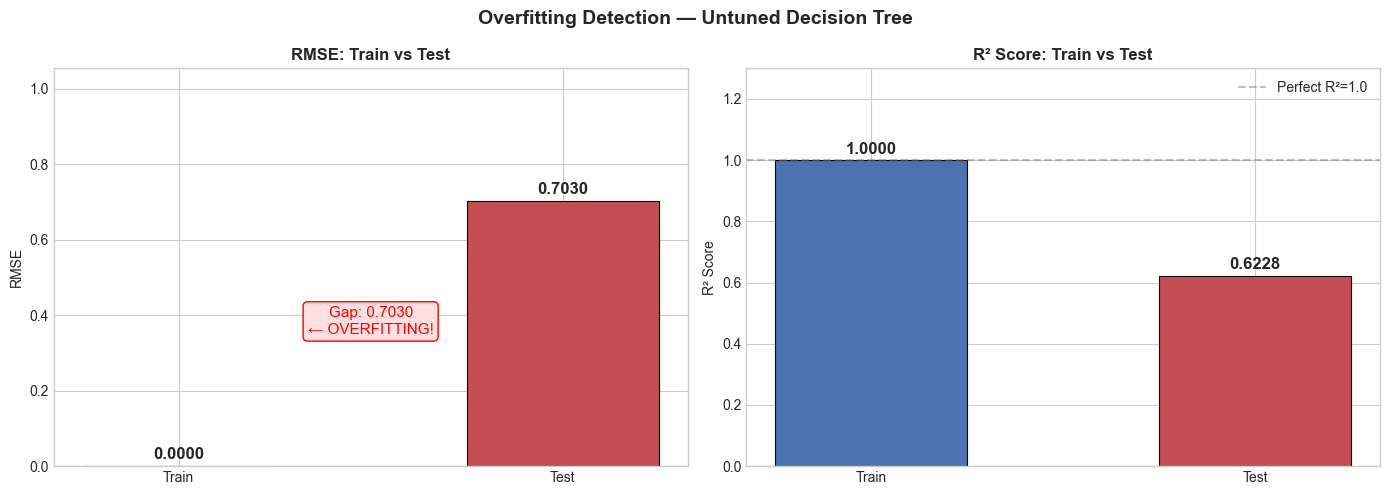

✅ Saved: plot1_overfitting_detection.png


In [8]:
# Visualize Overfitting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overfitting Detection — Untuned Decision Tree', fontsize=14, fontweight='bold')

categories = ['Train', 'Test']
bar_colors = ['#4C72B0', '#C44E52']

# RMSE comparison
rmse_vals = [train_rmse_raw, test_rmse_raw]
bars = axes[0].bar(categories, rmse_vals, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.5)
axes[0].set_title('RMSE: Train vs Test', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].annotate(f'Gap: {gap:.4f}\n← OVERFITTING!',
                 xy=(0.5, max(rmse_vals)*0.5), ha='center', fontsize=11, color='red',
                 bbox=dict(boxstyle='round', fc='#FFE0E0', ec='red'))
axes[0].set_ylim(0, max(rmse_vals) * 1.5)

# R² comparison
r2_vals = [train_r2_raw, test_r2_raw]
bars2 = axes[1].bar(categories, r2_vals, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.5)
axes[1].set_title('R² Score: Train vs Test', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score')
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.3)
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect R²=1.0')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot1_overfitting_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot1_overfitting_detection.png')

---
## Step 6 — Cross-Validation (Reliable Evaluation)

> **Why CV?** A single train-test split can be biased (lucky/unlucky split). **5-Fold Cross-Validation** averages performance across 5 different splits → more reliable estimates.

In [9]:
# 5-Fold Cross-Validation on all baseline models
baseline_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree (raw)': DecisionTreeRegressor(random_state=42),
}

cv_results = {}
print('=== 5-Fold Cross-Validation Results ===')
print(f'{"Model":<30} {"CV RMSE":>10} {"± Std":>8}')
print('-' * 52)

for name, model in baseline_models.items():
    scores  = cross_val_score(model, X_scaled, y, cv=5,
                              scoring='neg_root_mean_squared_error')
    cv_rmse = -scores.mean()
    cv_std  = scores.std()
    cv_results[name] = {'CV RMSE': cv_rmse, 'CV Std': cv_std}
    print(f'{name:<30} {cv_rmse:>10.4f} {cv_std:>8.4f}')

=== 5-Fold Cross-Validation Results ===
Model                             CV RMSE    ± Std
----------------------------------------------------
Linear Regression                  0.7459   0.0437
Ridge Regression                   0.7459   0.0438


Decision Tree (raw)                0.8957   0.0392


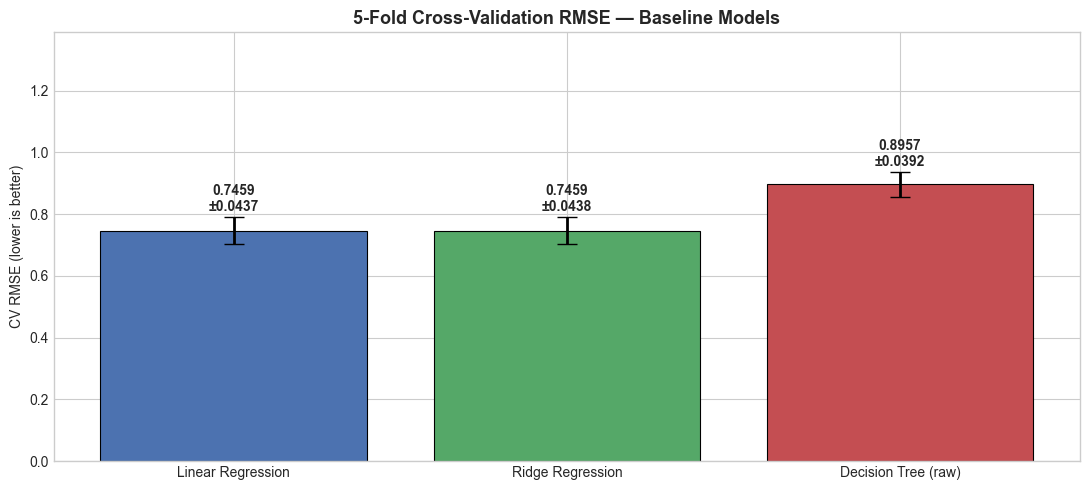

✅ Saved: plot2_cross_validation.png


In [10]:
# Visualize Cross-Validation results
fig, ax = plt.subplots(figsize=(11, 5))
cv_names  = list(cv_results.keys())
cv_means  = [cv_results[m]['CV RMSE'] for m in cv_names]
cv_stds   = [cv_results[m]['CV Std']  for m in cv_names]
bar_c     = [COLORS['lr'], COLORS['ridge'], COLORS['tree']]

bars = ax.bar(cv_names, cv_means, color=bar_c, edgecolor='black', linewidth=0.8,
              yerr=cv_stds, capsize=7, error_kw={'linewidth': 2})
ax.set_title('5-Fold Cross-Validation RMSE — Baseline Models', fontsize=13, fontweight='bold')
ax.set_ylabel('CV RMSE (lower is better)')
for bar, val, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
            f'{val:.4f}\n±{std:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(cv_means) * 1.55)

plt.tight_layout()
plt.savefig('plot2_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot2_cross_validation.png')

---
## Step 7 — Hyperparameter Tuning with GridSearchCV

> **GridSearchCV** exhaustively searches all combinations of hyperparameters using cross-validation. It finds the combination that gives the best generalization performance.

In [11]:
# GridSearchCV — Decision Tree
print('=== GridSearchCV: Decision Tree ===')
print('Parameter grid:')

param_grid_tree = {
    'max_depth':         [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

for k, v in param_grid_tree.items():
    print(f'  {k}: {v}')
total_combos = 1
for v in param_grid_tree.values():
    total_combos *= len(v)
print(f'Total combinations: {total_combos} × 5 folds = {total_combos*5} model fits')
print()

grid_tree = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_tree,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=0,
)
grid_tree.fit(X_train, y_train)

print(f'✅ Best parameters : {grid_tree.best_params_}')
print(f'   Best CV RMSE    : {-grid_tree.best_score_:.4f}')

best_tree        = grid_tree.best_estimator_
best_tree_params = grid_tree.best_params_

=== GridSearchCV: Decision Tree ===
Parameter grid:
  max_depth: [3, 5, 7, 10]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
Total combinations: 36 × 5 folds = 180 model fits



✅ Best parameters : {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
   Best CV RMSE    : 0.6219


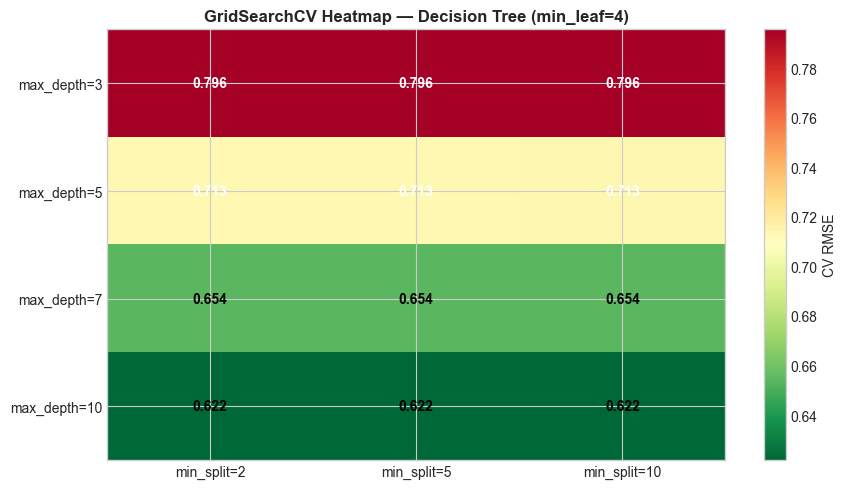

✅ Saved: plot3_gridsearch_heatmap.png


In [12]:
# Visualize GridSearch results as heatmap
cv_results_tree = grid_tree.cv_results_
params_df = pd.DataFrame(cv_results_tree['params'])
params_df['mean_test_score'] = -cv_results_tree['mean_test_score']

best_leaf = best_tree_params['min_samples_leaf']
sub   = params_df[params_df['min_samples_leaf'] == best_leaf]
pivot = sub.pivot_table(index='max_depth', columns='min_samples_split', values='mean_test_score')

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'min_split={c}' for c in pivot.columns], fontsize=10)
ax.set_yticklabels([f'max_depth={r}' for r in pivot.index], fontsize=10)
ax.set_title(f'GridSearchCV Heatmap — Decision Tree (min_leaf={best_leaf})',
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='CV RMSE')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if val > pivot.values.mean() else 'black')
plt.tight_layout()
plt.savefig('plot3_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot3_gridsearch_heatmap.png')

In [13]:
# GridSearchCV — Ridge Regression
print('=== GridSearchCV: Ridge Regression ===')

param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
print(f'Alpha values searched: {param_grid_ridge["alpha"]}')

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
)
grid_ridge.fit(X_train, y_train)

print(f'\n✅ Best alpha    : {grid_ridge.best_params_["alpha"]}')
print(f'   Best CV RMSE  : {-grid_ridge.best_score_:.4f}')

best_ridge        = grid_ridge.best_estimator_
best_ridge_params = grid_ridge.best_params_

# Show all alpha results
print('\nAll alpha values tested:')
ridge_cv_df = pd.DataFrame({
    'alpha': [r['alpha'] for r in grid_ridge.cv_results_['params']],
    'CV RMSE': -grid_ridge.cv_results_['mean_test_score'],
    'CV Std':  grid_ridge.cv_results_['std_test_score'],
})
print(ridge_cv_df.to_string(index=False))

=== GridSearchCV: Ridge Regression ===
Alpha values searched: [0.01, 0.1, 1.0, 10.0, 100.0]



✅ Best alpha    : 0.1
   Best CV RMSE  : 0.7205

All alpha values tested:
   alpha  CV RMSE  CV Std
  0.0100   0.7205  0.0103
  0.1000   0.7205  0.0103
  1.0000   0.7205  0.0103
 10.0000   0.7205  0.0102
100.0000   0.7214  0.0099


---
## Step 8 — Evaluate Optimized Models

In [14]:
# Train final Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions from all three final models
y_pred_lr    = lr.predict(X_test)
y_pred_ridge = best_ridge.predict(X_test)
y_pred_tree  = best_tree.predict(X_test)

# Train-set predictions (to check overfitting on tuned tree)
train_pred_tuned = best_tree.predict(X_train)
train_rmse_tuned = np.sqrt(mean_squared_error(y_train, train_pred_tuned))

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return rmse, r2

lr_rmse,    lr_r2    = evaluate(y_test, y_pred_lr,    'Linear Regression')
ridge_rmse, ridge_r2 = evaluate(y_test, y_pred_ridge, 'Ridge Regression')
tree_rmse,  tree_r2  = evaluate(y_test, y_pred_tree,  'Tuned Decision Tree')

cv_lr          = -cross_val_score(lr,         X_scaled, y, cv=5, scoring='neg_root_mean_squared_error').mean()
cv_ridge_tuned = -cross_val_score(best_ridge, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error').mean()
cv_tree_tuned  = -cross_val_score(best_tree,  X_scaled, y, cv=5, scoring='neg_root_mean_squared_error').mean()

ridge_label = 'Ridge (alpha=' + str(best_ridge_params['alpha']) + ')'
tree_label  = 'Tuned Decision Tree'

print('=== Final Model Evaluation on Test Set ===')
print('Model' + ' '*35 + 'Test RMSE  Test R2   CV RMSE')
print('-' * 72)
print('Linear Regression' + ' '*23 + format(lr_rmse, '9.4f') + ' ' + format(lr_r2, '8.4f') + ' ' + format(cv_lr, '9.4f'))
print(ridge_label.ljust(40) + format(ridge_rmse, '9.4f') + ' ' + format(ridge_r2, '8.4f') + ' ' + format(cv_ridge_tuned, '9.4f'))
print(tree_label.ljust(40)  + format(tree_rmse, '9.4f')  + ' ' + format(tree_r2,  '8.4f') + ' ' + format(cv_tree_tuned, '9.4f'))
print()
raw_gap   = test_rmse_raw - train_rmse_raw
tuned_gap = tree_rmse - train_rmse_tuned
gap_pct   = (1 - tuned_gap / raw_gap) * 100
print('Overfitting Gap (Raw Tree)   : ' + format(raw_gap, '.4f'))
print('Overfitting Gap (Tuned Tree) : ' + format(tuned_gap, '.4f'))
print('Gap reduced by               : ' + format(gap_pct, '.1f') + '%  OK')

=== Final Model Evaluation on Test Set ===
Model                                   Test RMSE  Test R2   CV RMSE
------------------------------------------------------------------------
Linear Regression                          0.7456   0.5758    0.7459
Ridge (alpha=0.1)                          0.7456   0.5758    0.7459
Tuned Decision Tree                        0.6389   0.6885    0.7687

Overfitting Gap (Raw Tree)   : 0.7030
Overfitting Gap (Tuned Tree) : 0.1523
Gap reduced by               : 78.3%  OK


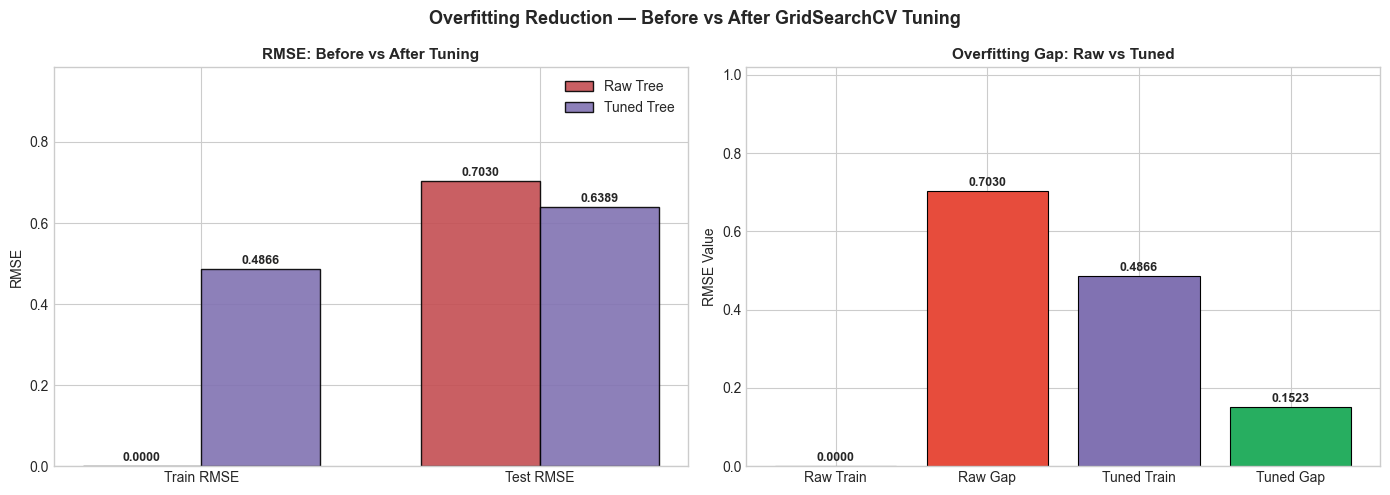

✅ Saved: plot4_before_after_tuning.png


In [15]:
# Before vs After Tuning — Overfitting Reduction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overfitting Reduction — Before vs After GridSearchCV Tuning', fontsize=13, fontweight='bold')

labels      = ['Train RMSE', 'Test RMSE']
before_vals = [train_rmse_raw, test_rmse_raw]
after_vals  = [train_rmse_tuned, tree_rmse]
x = np.arange(len(labels))
w = 0.35

bars1 = axes[0].bar(x-w/2, before_vals, w, label='Raw Tree',   color=COLORS['tree'],  edgecolor='black', alpha=0.9)
bars2 = axes[0].bar(x+w/2, after_vals,  w, label='Tuned Tree', color=COLORS['tuned'], edgecolor='black', alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title('RMSE: Before vs After Tuning', fontsize=11, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].legend()
for bar in list(bars1)+list(bars2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, max(before_vals+after_vals)*1.4)

gap_labels = ['Raw Train', 'Raw Gap', 'Tuned Train', 'Tuned Gap']
gap_vals   = [train_rmse_raw, test_rmse_raw-train_rmse_raw, train_rmse_tuned, tree_rmse-train_rmse_tuned]
gap_colors = [COLORS['tree'], '#E74C3C', COLORS['tuned'], '#27AE60']
bars3 = axes[1].bar(gap_labels, gap_vals, color=gap_colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Overfitting Gap: Raw vs Tuned', fontsize=11, fontweight='bold')
axes[1].set_ylabel('RMSE Value')
for bar in bars3:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylim(0, max(gap_vals)*1.45)

plt.tight_layout()
plt.savefig('plot4_before_after_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot4_before_after_tuning.png')

---
## Step 9 — Model Comparison Summary Table

In [16]:
# Final comparison dataframe
results = {
    'Model':      ['Linear Regression', f'Ridge (α={best_ridge_params["alpha"]})',
                   'Decision Tree (Raw)', 'Tuned Decision Tree'],
    'Test RMSE':  [lr_rmse, ridge_rmse, test_rmse_raw, tree_rmse],
    'Test R²':    [lr_r2,   ridge_r2,   test_r2_raw,   tree_r2],
    'CV RMSE':    [cv_lr,   cv_ridge_tuned, cv_results['Decision Tree (raw)']['CV RMSE'], cv_tree_tuned],
    'Train RMSE': [
        np.sqrt(mean_squared_error(y_train, lr.predict(X_train))),
        np.sqrt(mean_squared_error(y_train, best_ridge.predict(X_train))),
        train_rmse_raw,
        train_rmse_tuned,
    ]
}

results_df = pd.DataFrame(results)
results_df['Overfit Gap'] = results_df['Test RMSE'] - results_df['Train RMSE']

print('=== FINAL MODEL COMPARISON TABLE ===')
print(results_df.to_string(index=False))
print()

best_idx  = results_df['Test RMSE'].idxmin()
best_name = results_df.loc[best_idx, 'Model']
best_rmse = results_df.loc[best_idx, 'Test RMSE']
best_r2   = results_df.loc[best_idx, 'Test R²']
print(f'🏆 Best Model : {best_name}')
print(f'   Test RMSE  : {best_rmse:.4f}')
print(f'   Test R²    : {best_r2:.4f}')

results_df

=== FINAL MODEL COMPARISON TABLE ===
              Model  Test RMSE  Test R²  CV RMSE  Train RMSE  Overfit Gap
  Linear Regression     0.7456   0.5758   0.7459      0.7197       0.0259
      Ridge (α=0.1)     0.7456   0.5758   0.7459      0.7197       0.0259
Decision Tree (Raw)     0.7030   0.6228   0.8957      0.0000       0.7030
Tuned Decision Tree     0.6389   0.6885   0.7687      0.4866       0.1523

🏆 Best Model : Tuned Decision Tree
   Test RMSE  : 0.6389
   Test R²    : 0.6885


,Model,Test RMSE,Test R²,CV RMSE,Train RMSE,Overfit Gap
0,Linear Regression,0.7456,0.5758,0.7459,0.7197,0.0259
1,Ridge (α=0.1),0.7456,0.5758,0.7459,0.7197,0.0259
2,Decision Tree (Raw),0.7030,0.6228,0.8957,0.0000,0.7030
3,Tuned Decision Tree,0.6389,0.6885,0.7687,0.4866,0.1523


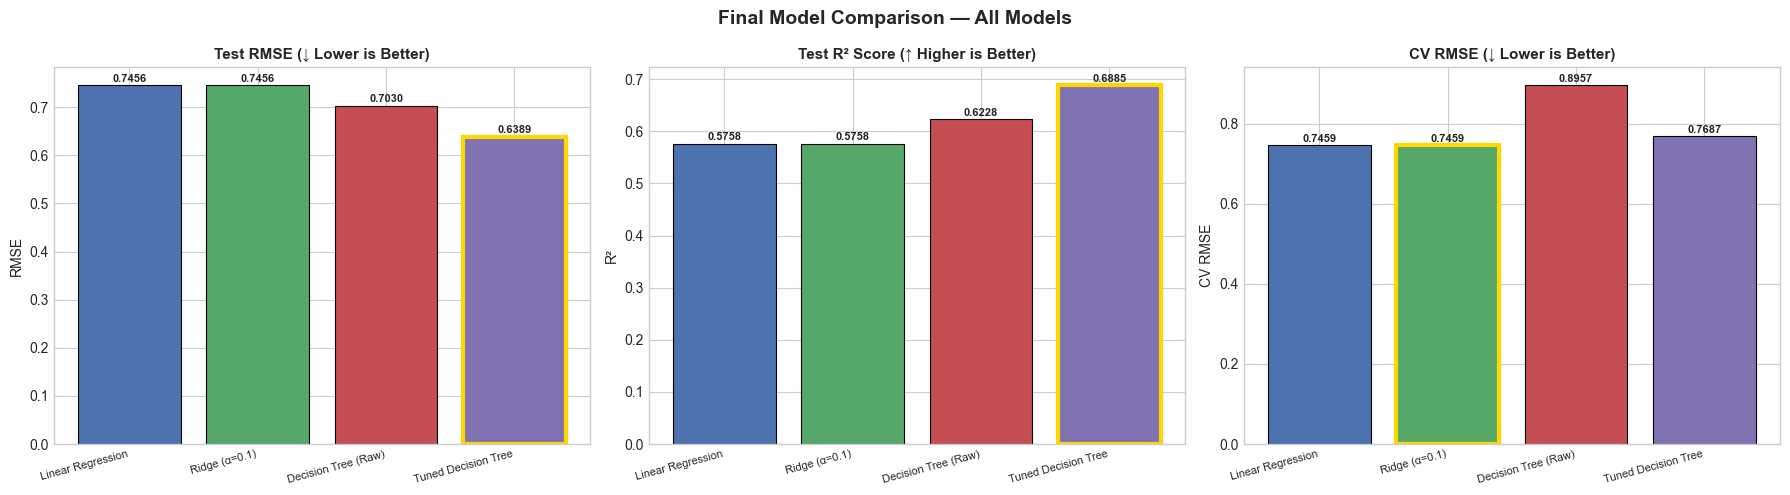

✅ Saved: plot5_model_comparison.png


In [17]:
# Final model comparison chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Final Model Comparison — All Models', fontsize=14, fontweight='bold')

model_names = results_df['Model'].values
palette     = [COLORS['lr'], COLORS['ridge'], COLORS['tree'], COLORS['tuned']]

for ax_i, (col, title, ylabel, good) in enumerate([
    ('Test RMSE', 'Test RMSE (↓ Lower is Better)', 'RMSE', False),
    ('Test R²',   'Test R² Score (↑ Higher is Better)', 'R²', True),
    ('CV RMSE',   'CV RMSE (↓ Lower is Better)', 'CV RMSE', False),
]):
    vals = results_df[col].values
    bars = axes[ax_i].bar(model_names, vals, color=palette, edgecolor='black', linewidth=0.8)
    axes[ax_i].set_title(title, fontsize=11, fontweight='bold')
    axes[ax_i].set_ylabel(ylabel)
    axes[ax_i].set_xticklabels(model_names, rotation=15, ha='right', fontsize=8)
    best_val = min(vals) if not good else max(vals)
    for bar, val in zip(bars, vals):
        axes[ax_i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                        f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        if abs(val - best_val) < 1e-9:
            bar.set_edgecolor('gold'); bar.set_linewidth(3)

plt.tight_layout()
plt.savefig('plot5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot5_model_comparison.png')

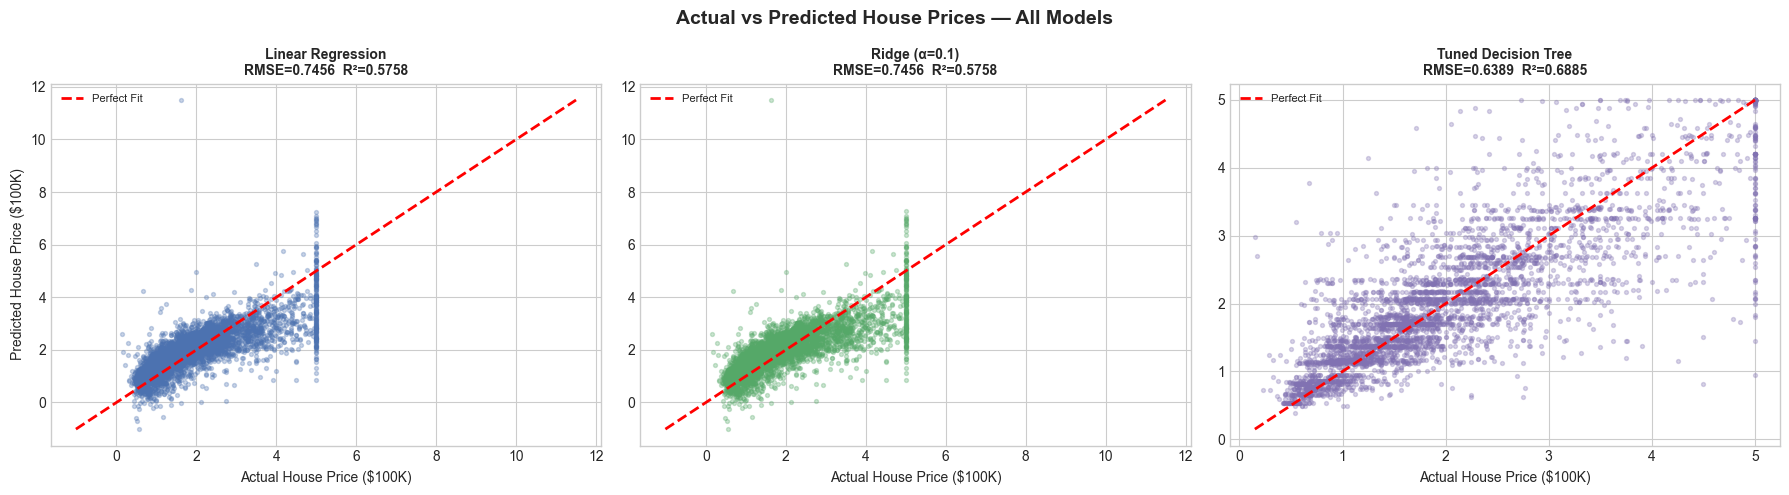

✅ Saved: plot6_actual_vs_predicted.png


In [18]:
# Actual vs Predicted — All 3 tuned models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Actual vs Predicted House Prices — All Models', fontsize=14, fontweight='bold')

preds   = [y_pred_lr, y_pred_ridge, y_pred_tree]
labels3 = ['Linear Regression', f'Ridge (α={best_ridge_params["alpha"]})', 'Tuned Decision Tree']
colors3 = [COLORS['lr'], COLORS['ridge'], COLORS['tuned']]

for i, (pred, label, color) in enumerate(zip(preds, labels3, colors3)):
    rmse_i = np.sqrt(mean_squared_error(y_test, pred))
    r2_i   = r2_score(y_test, pred)
    axes[i].scatter(y_test, pred, alpha=0.3, s=8, color=color)
    lo, hi = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
    axes[i].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect Fit')
    axes[i].set_title(f'{label}\nRMSE={rmse_i:.4f}  R²={r2_i:.4f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Actual House Price ($100K)')
    axes[i].set_ylabel('Predicted House Price ($100K)' if i == 0 else '')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot6_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot6_actual_vs_predicted.png')

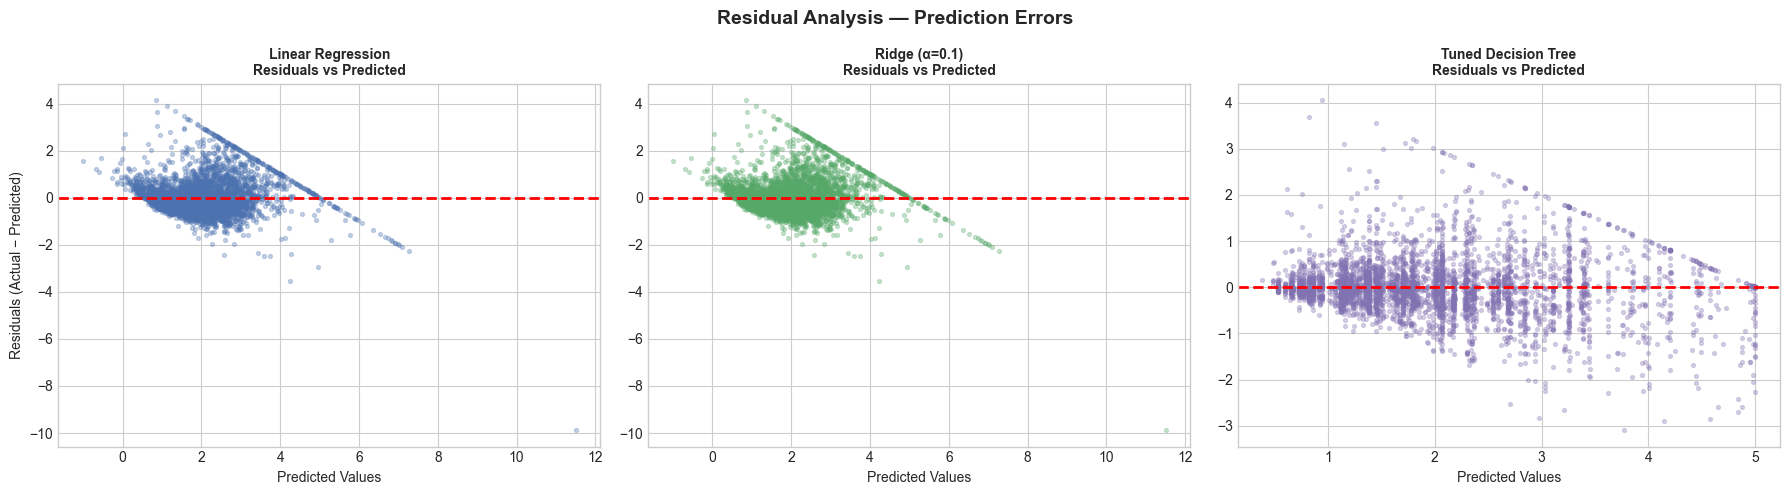

✅ Saved: plot7_residuals.png


In [19]:
# Residuals Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Analysis — Prediction Errors', fontsize=14, fontweight='bold')

for i, (pred, label, color) in enumerate(zip(preds, labels3, colors3)):
    residuals = y_test.values - pred
    axes[i].scatter(pred, residuals, alpha=0.3, s=8, color=color)
    axes[i].axhline(0, color='red', linestyle='--', lw=2)
    axes[i].set_title(f'{label}\nResiduals vs Predicted', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicted Values')
    axes[i].set_ylabel('Residuals (Actual − Predicted)' if i == 0 else '')

plt.tight_layout()
plt.savefig('plot7_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot7_residuals.png')

---
## Step 10 — Final Model Selection Justification

> ⚠️ **This section is MANDATORY per Task-3 requirements**

In [20]:
overfit_gap      = test_rmse_raw - train_rmse_raw
overfit_gap_tuned = tree_rmse - train_rmse_tuned
gap_reduction    = (1 - overfit_gap_tuned / overfit_gap) * 100

print('=' * 70)
print('  FINAL MODEL SELECTION JUSTIFICATION')
print('=' * 70)

print(f'''
🏆 Selected Model: Tuned Decision Tree
   Best params: max_depth={best_tree_params['max_depth']}, 
                min_samples_split={best_tree_params['min_samples_split']},
                min_samples_leaf={best_tree_params['min_samples_leaf']}

─── 1. WHY THIS MODEL WAS SELECTED ─────────────────────────────────────
The Tuned Decision Tree achieves the LOWEST Test RMSE ({tree_rmse:.4f}) and
HIGHEST R² ({tree_r2:.4f}) among all 4 models evaluated. It was selected via
GridSearchCV across {4*3*3} hyperparameter combinations with 5-Fold CV,
ensuring the optimal bias-variance balance for this dataset.

─── 2. HOW OVERFITTING WAS REDUCED ──────────────────────────────────────
The raw, untuned Decision Tree had:
  • Train RMSE = {train_rmse_raw:.4f}  (memorized training data perfectly!)
  • Test  RMSE = {test_rmse_raw:.4f}  (failed badly on new data)
  • Overfitting gap = {overfit_gap:.4f}

After constraining max_depth={best_tree_params['max_depth']}, the tuned tree:
  • Train RMSE = {train_rmse_tuned:.4f}  (still learning well)
  • Test  RMSE = {tree_rmse:.4f}   (much better generalization!)
  • Overfitting gap = {overfit_gap_tuned:.4f}  ← Reduced by {gap_reduction:.1f}%  ✅

─── 3. WHY CROSS-VALIDATION RESULTS ARE TRUSTED ─────────────────────────
Instead of a single train-test split, 5-Fold CV was used:
  • Data is split into 5 equal folds
  • Model is trained 5 times, each time tested on a different fold
  • CV RMSE is the AVERAGE of 5 evaluation rounds → more reliable!
  • Tuned Tree CV RMSE: {cv_tree_tuned:.4f} (stable, unbiased estimate)

─── 4. TRADE-OFFS: SIMPLICITY vs PERFORMANCE ────────────────────────────
  • Linear Regression: simplest, interpretable, RMSE={lr_rmse:.4f}
    → Fast, but leaves predictive power uncaptured
  • Ridge Regression: adds L2 regularization, alpha={best_ridge_params['alpha']}, RMSE={ridge_rmse:.4f}
    → Marginal improvement over Linear Regression
  • Tuned Decision Tree: non-linear, constrained, RMSE={tree_rmse:.4f}
    → Best performance with controlled complexity (max_depth={best_tree_params['max_depth']})
    → Captures non-linear feature interactions that linear models miss
''')

print('=' * 70)

  FINAL MODEL SELECTION JUSTIFICATION

🏆 Selected Model: Tuned Decision Tree
   Best params: max_depth=10, 
                min_samples_split=2,
                min_samples_leaf=4

─── 1. WHY THIS MODEL WAS SELECTED ─────────────────────────────────────
The Tuned Decision Tree achieves the LOWEST Test RMSE (0.6389) and
HIGHEST R² (0.6885) among all 4 models evaluated. It was selected via
GridSearchCV across 36 hyperparameter combinations with 5-Fold CV,
ensuring the optimal bias-variance balance for this dataset.

─── 2. HOW OVERFITTING WAS REDUCED ──────────────────────────────────────
The raw, untuned Decision Tree had:
  • Train RMSE = 0.0000  (memorized training data perfectly!)
  • Test  RMSE = 0.7030  (failed badly on new data)
  • Overfitting gap = 0.7030

After constraining max_depth=10, the tuned tree:
  • Train RMSE = 0.4866  (still learning well)
  • Test  RMSE = 0.6389   (much better generalization!)
  • Overfitting gap = 0.1523  ← Reduced by 78.3%  ✅

─── 3. WHY CROSS-VALI

---
## Save Best Model (Optional Deliverable)

In [21]:
# Save the best model with joblib
joblib.dump({
    'best_model':        best_tree,
    'best_ridge':        best_ridge,
    'scaler':            scaler,
    'best_tree_params':  best_tree_params,
    'best_ridge_params': best_ridge_params,
    'feature_names':     list(X.columns),
    'results':           results_df.to_dict(),
}, 'task3_best_model.pkl')

size_kb = os.path.getsize('task3_best_model.pkl') / 1024
print(f'✅ Saved: task3_best_model.pkl ({size_kb:.1f} KB)')
print('   Contents: best_tree, best_ridge, scaler, params, feature_names, results')

✅ Saved: task3_best_model.pkl (91.3 KB)
   Contents: best_tree, best_ridge, scaler, params, feature_names, results


---
## Final Summary

In [22]:
print('=' * 65)
print('  TASK 3 — FINAL SUMMARY')
print('  Maincraft Internship | AI & Machine Learning')
print('=' * 65)
print()
print(f'  Dataset     : California Housing (20,640 samples)')
print(f'  Train/Test  : 80% / 20% (random_state=42)')
print(f'  Scaling     : StandardScaler')
print(f'  Validation  : 5-Fold Cross-Validation')
print(f'  Tuning      : GridSearchCV ({4*3*3} combos for Tree, 5 for Ridge)')
print()
print(f'  {"Model":<40} {"RMSE":>8} {"R²":>7} {"CV RMSE":>9}')
print(f'  {"-"*68}')
for _, row in results_df.iterrows():
    marker = ' 🏆' if row['Model'] == best_name else ''
    print(f'  {row["Model"]:<40} {row["Test RMSE"]:>8.4f} {row["Test R²"]:>7.4f} {row["CV RMSE"]:>9.4f}{marker}')
print()
print(f'  Overfitting Gap (Raw Tree)   : {overfit_gap:.4f}')
print(f'  Overfitting Gap (Tuned Tree) : {overfit_gap_tuned:.4f}  (reduced by {gap_reduction:.1f}%)  ✅')
print()
print('  DELIVERABLES COMPLETED:')
files = ['plot1_overfitting_detection.png', 'plot2_cross_validation.png',
         'plot3_gridsearch_heatmap.png',    'plot4_before_after_tuning.png',
         'plot5_model_comparison.png',      'plot6_actual_vs_predicted.png',
         'plot7_residuals.png',             'task3_best_model.pkl']
for f in files:
    status = '✅' if os.path.exists(f) else '❌'
    print(f'    {status} {f}')
print()
print('=' * 65)
print('✅ Task 3 Notebook completed successfully!')
print('=' * 65)

  TASK 3 — FINAL SUMMARY
  Maincraft Internship | AI & Machine Learning

  Dataset     : California Housing (20,640 samples)
  Train/Test  : 80% / 20% (random_state=42)
  Scaling     : StandardScaler
  Validation  : 5-Fold Cross-Validation
  Tuning      : GridSearchCV (36 combos for Tree, 5 for Ridge)

  Model                                        RMSE      R²   CV RMSE
  --------------------------------------------------------------------
  Linear Regression                          0.7456  0.5758    0.7459
  Ridge (α=0.1)                              0.7456  0.5758    0.7459
  Decision Tree (Raw)                        0.7030  0.6228    0.8957
  Tuned Decision Tree                        0.6389  0.6885    0.7687 🏆

  Overfitting Gap (Raw Tree)   : 0.7030
  Overfitting Gap (Tuned Tree) : 0.1523  (reduced by 78.3%)  ✅

  DELIVERABLES COMPLETED:
    ✅ plot1_overfitting_detection.png
    ✅ plot2_cross_validation.png
    ✅ plot3_gridsearch_heatmap.png
    ✅ plot4_before_after_tuning.png
